In [16]:
from pdbtools import *
import torch
import matplotlib.pyplot as plt
import potential
import atom

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Download PDB file

In [2]:
filename = fetch_pdb_file("6drv")
filename

'6DRV.pdb'

## Extract atomic coordinates and recenter onto (0,0,0)

In [3]:
# extracts raw coordinates for each atom in (x,y,z) order from pdb file
atomic_numbers, coords = get_atoms_and_coordinates_from_pdb(filename)
atomic_numbers.shape, coords.shape

((32888,), (32888, 3))

In [4]:
# elements in particle
print(set(atom_symbol(atomic_numbers)))

{'O', 'C', 'S', 'N'}


In [5]:
# recenters coordinates onto origin (0,0,0)
center = center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

[122.2525 122.37   122.275 ]


## Compute 2D atomic scattering potentials

In [151]:
n = 100
x = torch.linspace(-2.5, 2.5, n)
dx = x[1] - x[0]
y = x.clone()
X, Y = torch.meshgrid(x,y, indexing='xy')
R = torch.sqrt(X**2 + Y**2)

In [152]:
pot2d = potential.atomic_potential_2d(atomic_numbers[0], R, dx)

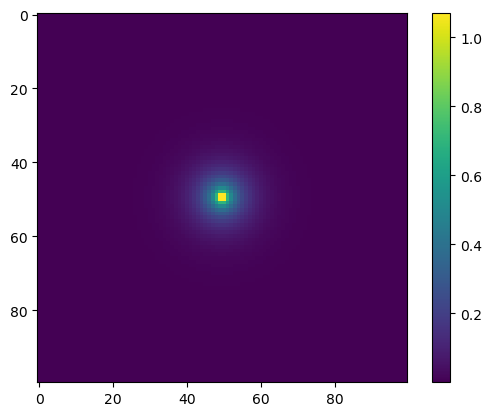

In [153]:
plt.imshow(pot2d)
plt.colorbar()

## Compute 3D atomic potential

In [154]:
x = torch.linspace(-2.5, 2.5, n)
y = x.clone()
z = x.clone()
X, Y, Z = torch.meshgrid(x,y,z, indexing='xy')
R = torch.sqrt(X**2 + Y**2 + Z**2)

In [155]:
pot3d = potential.atomic_potential_3d(atomic_numbers[0], R, dx)

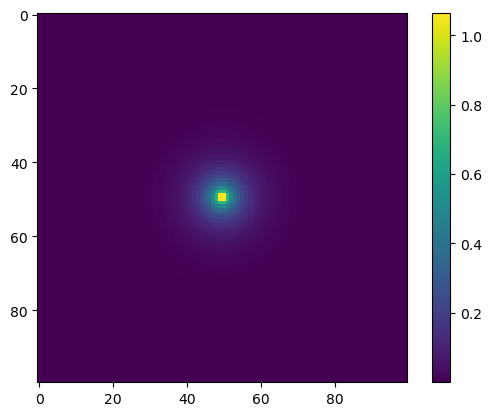

In [156]:
plt.imshow(torch.sum(pot3d,0))
plt.colorbar()